# Benchmark vs Sorcha ROC (mag245 n-body) — full sky, by elongation, by magnitude

One classifier (VDP, and digest2 as reference), two populations: the pure-S3M **benchmark**
(`outputs/phase2_benchmark_s3m_nbody_mag245/benchmark_comparison_s3m_nbody_mag245.parquet`, 666,786 objects, V<24.5) vs **Sorcha case1**
(`sorcha_comparison_case1_nbody_Vband.parquet`, 648,769 tracklets, full 2-yr / 606 nights).
Both scored against the same n-body maps, in Johnson V.

Benchmark headline ROC uses the full mag245 benchmark directly: the faint unscorable tail from the
uncut benchmark has already been removed. Sorcha is still filtered to `mag_bin_label_Vband.notna()`
because it is a detected set and nearly all rows are scorable. Magnitude-bin panels naturally use
rows with a populated `mag_bin_label`.

House style: x = completeness (%), y = contamination (%), lower-right is better. Colour = pipeline
(blue = benchmark, red = Sorcha); line style = classifier (solid = VDP, dashed = digest2).


In [1]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, roc_auc_score, roc_curve

C_BENCH, C_SORCHA = 'tab:blue', 'tab:red'

def roc_xy(yy, s):
    """(completeness%, contamination%, bestF1, best_compl%, best_contam%)"""
    p, r, _ = precision_recall_curve(yy, s)
    f1 = np.divide(2*p*r, p+r, out=np.zeros_like(p), where=(p+r) > 0)
    bi = int(np.argmax(f1[:-1]))
    return r*100, (1-p)*100, f1[bi], r[bi]*100, (1-p[bi])*100

# ---- load benchmark full-set, filter Sorcha to scorable, add absdlon ----
bench = pd.read_parquet('outputs/phase2_benchmark_s3m_nbody_mag245/benchmark_comparison_s3m_nbody_mag245.parquet',
    columns=['population','mag_bin_label','dlon_from_antisun_deg','P_NEO_vdp','P_NEO_d2'])
bench = bench.copy()
bench['absdlon'] = bench.dlon_from_antisun_deg.abs()
bench['is_neo']  = (bench.population == 'NEO').astype(int)

sorcha = pd.read_parquet('sorcha_comparison_case1_nbody_Vband.parquet',
    columns=['population','mag_bin_label_Vband','prob_map_file','P_NEO_vdp_Vband','P_NEO_d2'])
sorcha = sorcha[sorcha.mag_bin_label_Vband.notna()].copy()
sorcha = sorcha.rename(columns={'mag_bin_label_Vband':'mag_bin_label','P_NEO_vdp_Vband':'P_NEO_vdp'})
def _absdlon(pmf):
    m = re.search(r'dlon([+-]\d+)', str(pmf))
    return abs(int(m.group(1))) if m else np.nan
sorcha['absdlon'] = sorcha.prob_map_file.map(_absdlon)
sorcha['is_neo']  = (sorcha.population == 'NEO').astype(int)

print(f'benchmark mag245: {len(bench):,} rows, {bench.is_neo.sum():,} NEO')
print(f'sorcha:    {len(sorcha):,} scorable, {sorcha.is_neo.sum():,} NEO  (full 2yr, 606 nights)')

benchmark mag245: 666,786 rows, 9,186 NEO
sorcha:    648,296 scorable, 148,634 NEO  (full 2yr, 606 nights)


## 1. Full-sky ROC

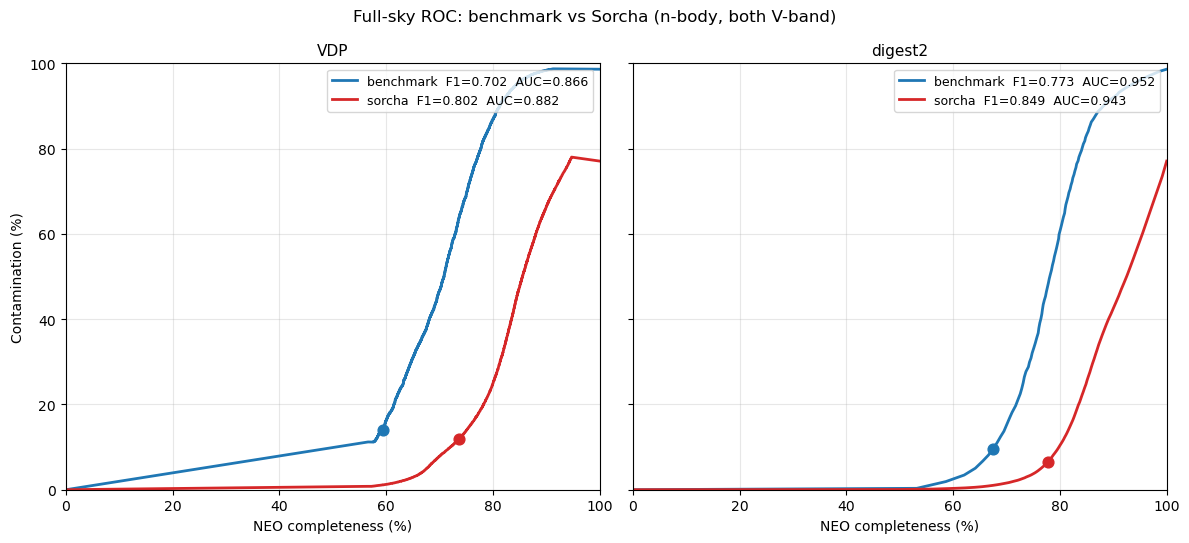

=== full-sky summary ===


N   N_NEO     F1    AUC  compl%  contam%
classifier dataset                                                 
VDP        benchmark  666786    9186  0.702  0.866    59.4     14.1
           sorcha     648296  148634  0.802  0.882    73.7     11.9
digest2    benchmark  666786    9186  0.773  0.952    67.5      9.6
           sorcha     648296  148634  0.849  0.943    77.8      6.6

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5.5), sharex=True, sharey=True)
rows = []
for ax, (score_col, title) in zip(axes, [('P_NEO_vdp','VDP'), ('P_NEO_d2','digest2')]):
    for df, name, col in [(bench,'benchmark',C_BENCH), (sorcha,'sorcha',C_SORCHA)]:
        yy = df.is_neo.values
        c, k, f1, mc, mk = roc_xy(yy, df[score_col].values)
        auc = roc_auc_score(yy, df[score_col].values)
        ax.plot(c, k, lw=2, color=col, label=f'{name}  F1={f1:.3f}  AUC={auc:.3f}')
        ax.scatter([mc], [mk], color=col, s=60, zorder=5)
        rows.append({'classifier': title, 'dataset': name, 'N': len(df), 'N_NEO': int(yy.sum()),
                     'F1': round(f1,3), 'AUC': round(auc,3), 'compl%': round(mc,1), 'contam%': round(mk,1)})
    ax.set_xlim(0,100); ax.set_ylim(0,100); ax.grid(alpha=0.3)
    ax.set_xlabel('NEO completeness (%)')
    ax.set_title(title, fontsize=11)
    ax.legend(fontsize=9, loc='upper right')
axes[0].set_ylabel('Contamination (%)')
fig.suptitle('Full-sky ROC: benchmark vs Sorcha (n-body, both V-band)', fontsize=12)
plt.tight_layout()
plt.savefig('Figures/mag245_nbody_bvs_fullsky_roc.png', dpi=150, bbox_inches='tight')
plt.show()

print('=== full-sky summary ===')
display(pd.DataFrame(rows).set_index(['classifier','dataset']))

### 1.A VDP vs digest2 within each dataset

These are precision-recall-derived curves: completeness is recall, and contamination is `1 - precision`. They are not conventional ROC curves (true-positive rate vs false-positive rate).

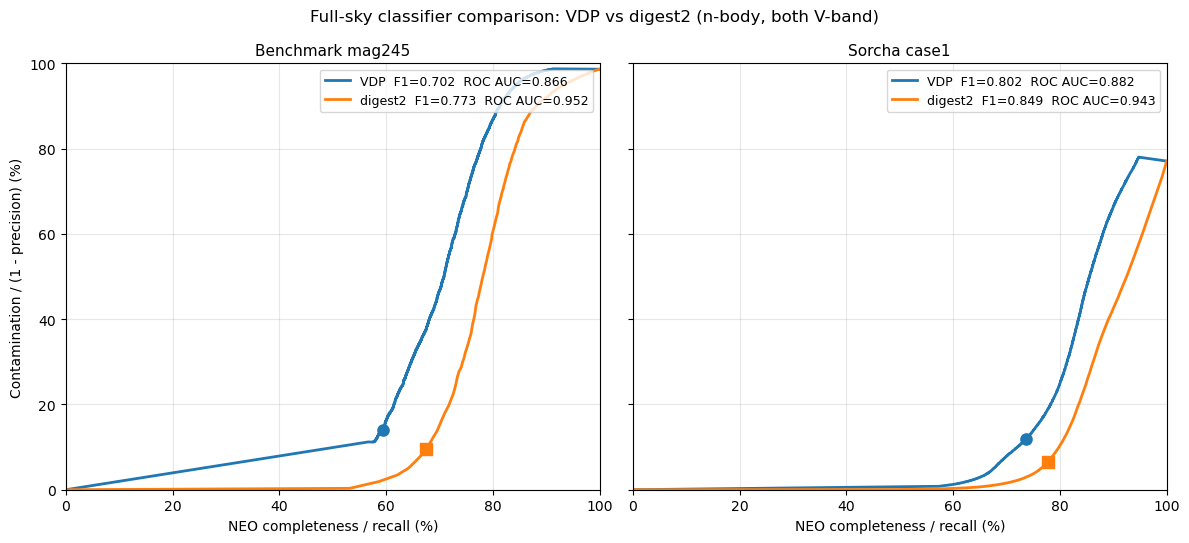

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5.5), sharex=True, sharey=True)
classifiers = [
    ('P_NEO_vdp', 'VDP', 'tab:blue', 'o'),
    ('P_NEO_d2', 'digest2', 'tab:orange', 's'),
]

for ax, (df, dataset_name) in zip(axes, [(bench, 'Benchmark mag245'), (sorcha, 'Sorcha case1')]):
    yy = df.is_neo.values
    for score_col, classifier_name, color, marker in classifiers:
        c, k, f1, mc, mk = roc_xy(yy, df[score_col].values)
        auc = roc_auc_score(yy, df[score_col].values)
        ax.plot(c, k, lw=2, color=color,
                label=f'{classifier_name}  F1={f1:.3f}  ROC AUC={auc:.3f}')
        ax.scatter([mc], [mk], color=color, marker=marker, s=65, zorder=5)

    ax.set_xlim(0, 100); ax.set_ylim(0, 100); ax.grid(alpha=0.3)
    ax.set_xlabel('NEO completeness / recall (%)')
    ax.set_title(dataset_name, fontsize=11)
    ax.legend(fontsize=9, loc='upper right')

axes[0].set_ylabel('Contamination / (1 - precision) (%)')
fig.suptitle('Full-sky classifier comparison: VDP vs digest2 (n-body, both V-band)', fontsize=12)
plt.tight_layout()
plt.savefig('Figures/mag245_nbody_vdp_vs_digest2_by_dataset.png', dpi=150, bbox_inches='tight')
plt.show()

### 1.B ROC curves and area under the curve

ROC AUC is the area under the conventional ROC curve: NEO true-positive rate (completeness) versus non-NEO false-positive rate. The diagonal is random classification (`AUC = 0.5`); curves closer to the upper-left corner are better.

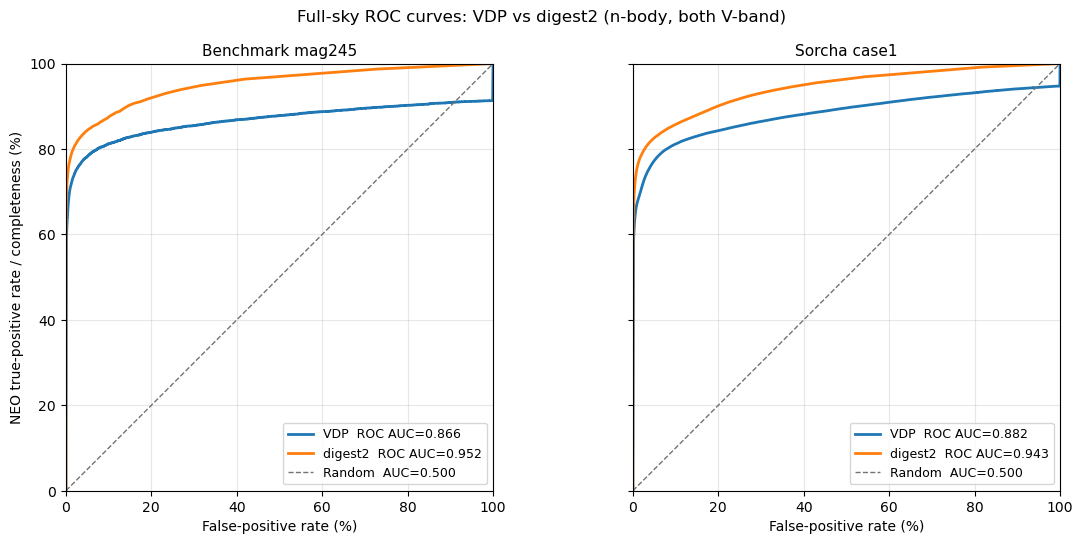

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5.5), sharex=True, sharey=True)

for ax, (df, dataset_name) in zip(axes, [(bench, 'Benchmark mag245'), (sorcha, 'Sorcha case1')]):
    yy = df.is_neo.values
    for score_col, classifier_name, color, _ in classifiers:
        scores = df[score_col].values
        fpr, tpr, _ = roc_curve(yy, scores)
        auc = roc_auc_score(yy, scores)
        ax.plot(fpr * 100, tpr * 100, lw=2, color=color,
                label=f'{classifier_name}  ROC AUC={auc:.3f}')

    ax.plot([0, 100], [0, 100], color='0.45', lw=1, ls='--', label='Random  AUC=0.500')
    ax.set_xlim(0, 100); ax.set_ylim(0, 100); ax.grid(alpha=0.3)
    ax.set_xlabel('False-positive rate (%)')
    ax.set_title(dataset_name, fontsize=11)
    ax.legend(fontsize=9, loc='lower right')
    ax.set_aspect('equal', adjustable='box')

axes[0].set_ylabel('NEO true-positive rate / completeness (%)')
fig.suptitle('Full-sky ROC curves: VDP vs digest2 (n-body, both V-band)', fontsize=12)
plt.tight_layout()
plt.savefig('Figures/mag245_nbody_vdp_vs_digest2_roc_auc.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Broken by elongation ($|\Delta\lambda_\odot|$ from antisun)

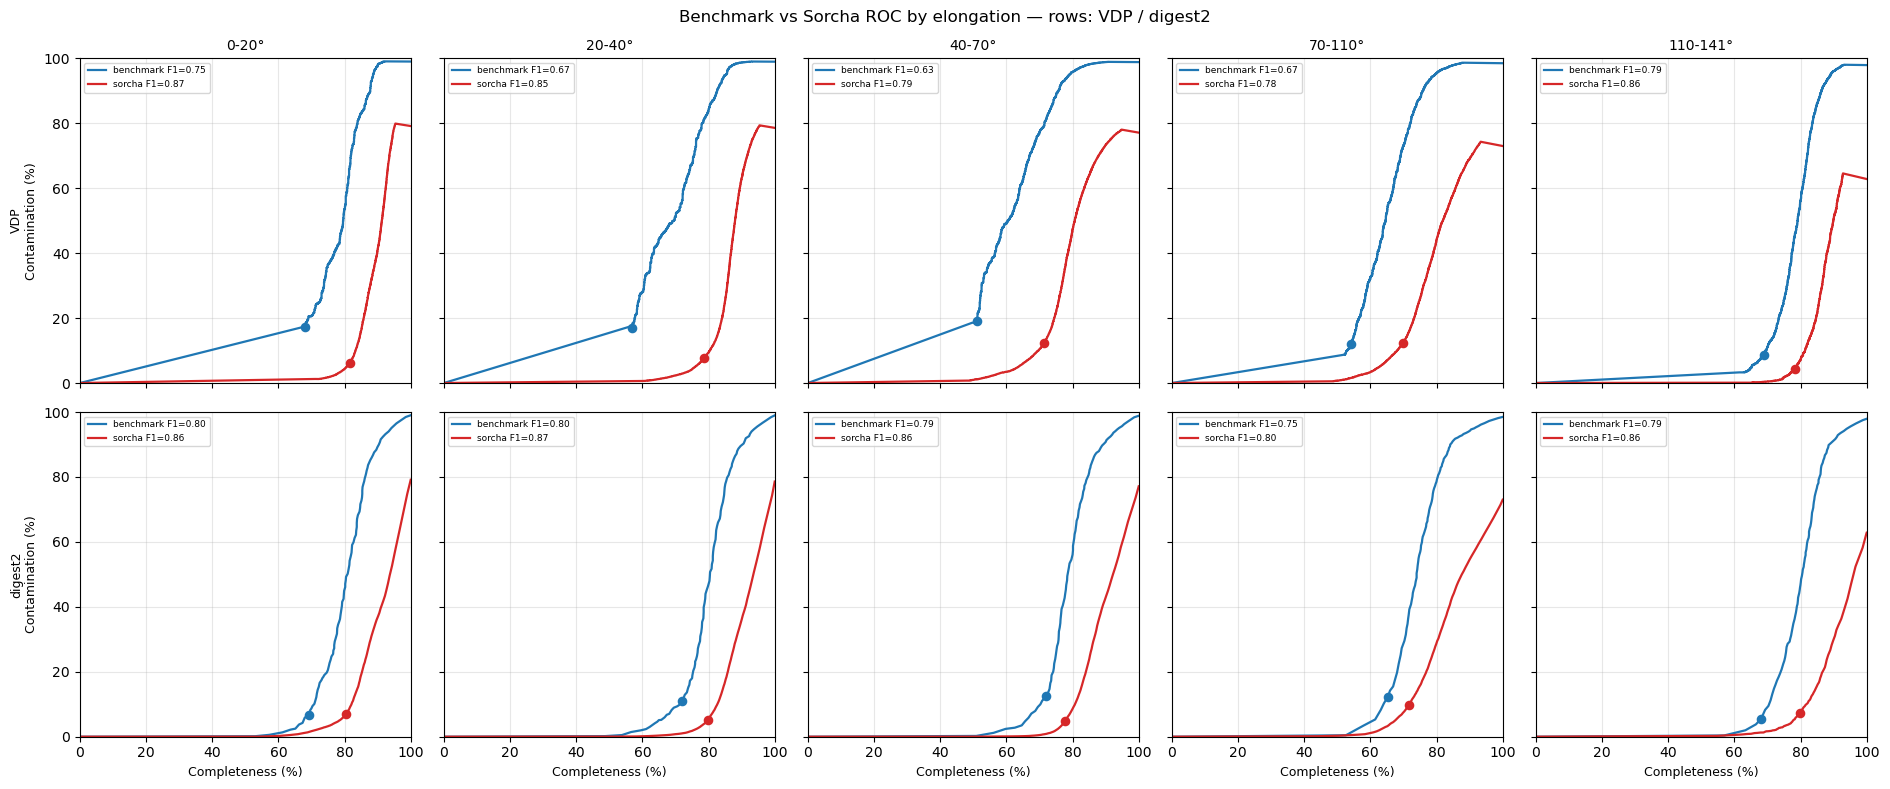

=== per-elongation summary ===


classifier       VDP          digest2       
dataset    benchmark sorcha benchmark sorcha
bin                                         
0-20°          0.747  0.873     0.796  0.863
110-141°       0.785  0.861     0.791  0.858
20-40°         0.675  0.850     0.796  0.866
40-70°         0.627  0.787     0.790  0.856
70-110°        0.671  0.778     0.749  0.798

In [5]:
BINS = [(0,20),(20,40),(40,70),(70,110),(110,141)]
BIN_LABS = ['0-20°','20-40°','40-70°','70-110°','110-141°']
MIN_NEO = 15

fig, axes = plt.subplots(2, len(BINS), figsize=(19, 8), sharex=True, sharey=True)
elong_rows = []
for ci, (score_col, title) in enumerate([('P_NEO_vdp','VDP'), ('P_NEO_d2','digest2')]):
    for bi, ((lo,hi), blab) in enumerate(zip(BINS, BIN_LABS)):
        ax = axes[ci, bi]
        for df, name, col in [(bench,'benchmark',C_BENCH), (sorcha,'sorcha',C_SORCHA)]:
            m = ((df.absdlon >= lo) & (df.absdlon < hi)).values
            yy = df.is_neo.values[m]
            if yy.sum() < MIN_NEO or (~yy.astype(bool)).sum() < MIN_NEO:
                continue
            c, k, f1, mc, mk = roc_xy(yy, df[score_col].values[m])
            ax.plot(c, k, lw=1.6, color=col, label=f'{name} F1={f1:.2f}')
            ax.scatter([mc],[mk], color=col, s=35, zorder=5)
            elong_rows.append({'classifier':title,'bin':blab,'dataset':name,
                               'N_NEO':int(yy.sum()),'F1':round(f1,3)})
        ax.set_xlim(0,100); ax.set_ylim(0,100); ax.grid(alpha=0.3)
        ax.legend(fontsize=6.5, loc='upper left')
        if ci == 0: ax.set_title(blab, fontsize=10)
        if bi == 0: ax.set_ylabel(f'{title}\nContamination (%)', fontsize=9)
for ax in axes[-1,:]: ax.set_xlabel('Completeness (%)', fontsize=9)
fig.suptitle('Benchmark vs Sorcha ROC by elongation — rows: VDP / digest2', fontsize=12)
plt.tight_layout()
plt.savefig('Figures/mag245_nbody_bvs_elongation_roc.png', dpi=150, bbox_inches='tight')
plt.show()

print('=== per-elongation summary ===')
display(pd.DataFrame(elong_rows).pivot_table(index=['bin'], columns=['classifier','dataset'], values='F1'))

## 3. Broken by magnitude bin

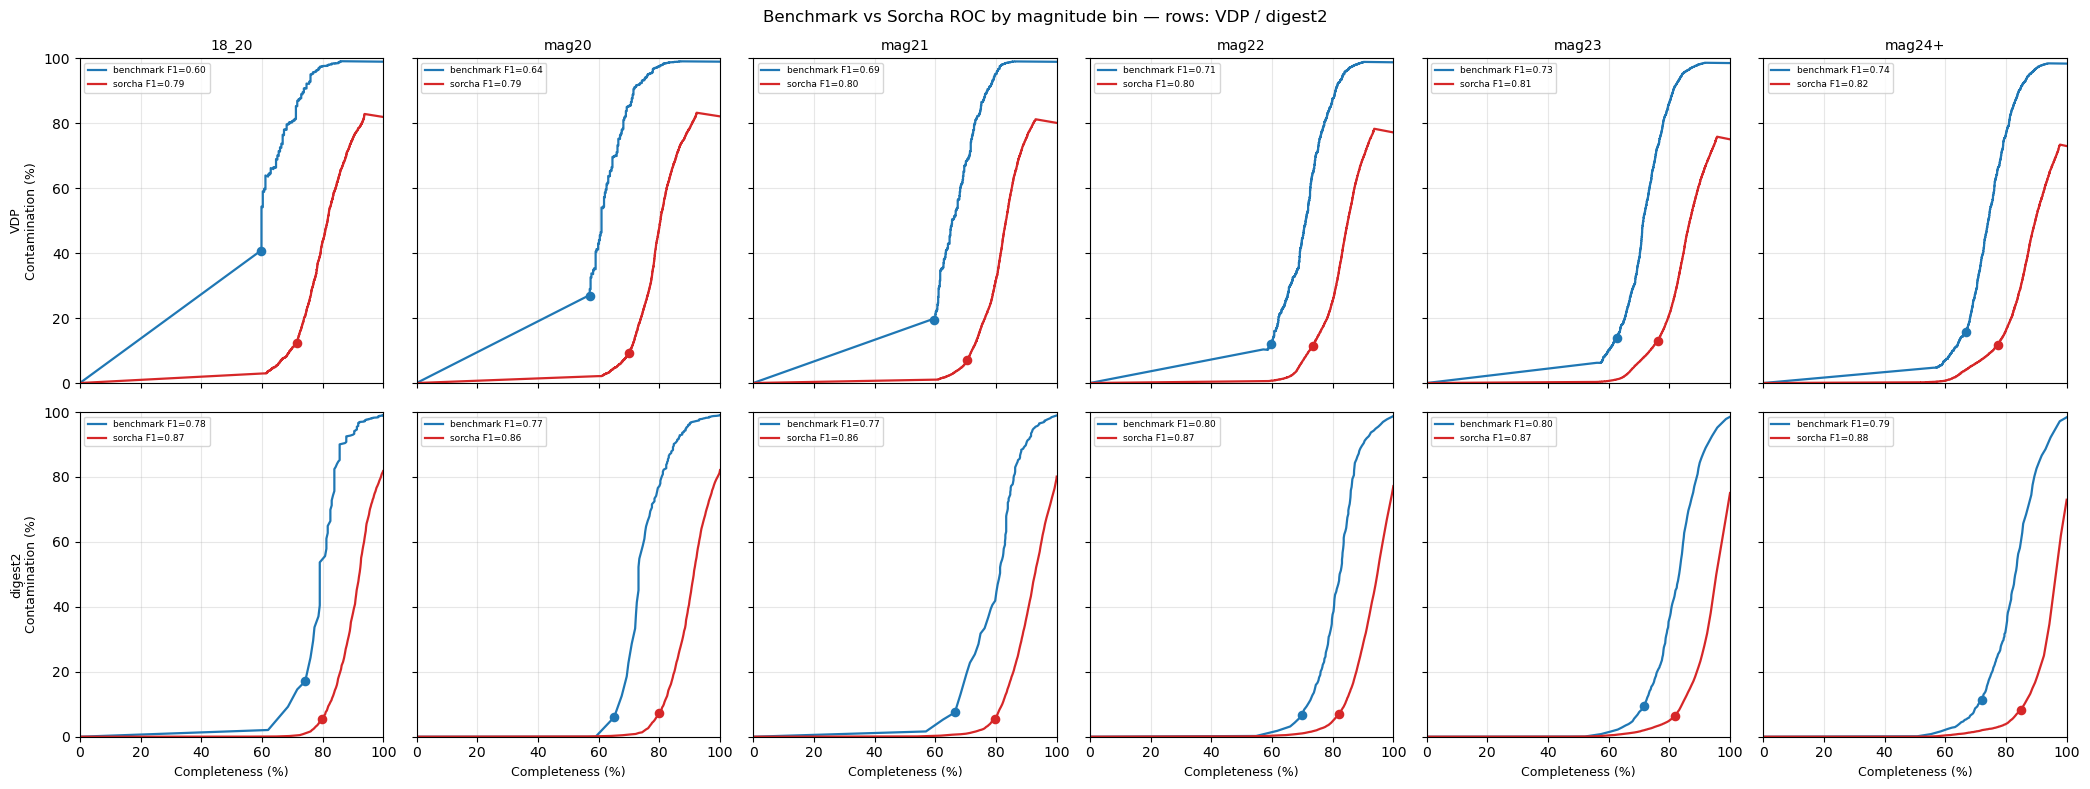

=== per-magnitude-bin summary ===


classifier       VDP          digest2       
dataset    benchmark sorcha benchmark sorcha
mag_bin                                     
18_20          0.596  0.786     0.783  0.865
mag20          0.641  0.790     0.769  0.859
mag21          0.686  0.802     0.773  0.864
mag22          0.713  0.803     0.799  0.872
mag23          0.726  0.812     0.801  0.873
mag24+         0.744  0.824     0.794  0.882

In [6]:
MAG_BINS = ['18_20','mag20','mag21','mag22','mag23','mag24+']

fig, axes = plt.subplots(2, len(MAG_BINS), figsize=(21, 8), sharex=True, sharey=True)
mag_rows = []
for ci, (score_col, title) in enumerate([('P_NEO_vdp','VDP'), ('P_NEO_d2','digest2')]):
    for bi, mb in enumerate(MAG_BINS):
        ax = axes[ci, bi]
        for df, name, col in [(bench,'benchmark',C_BENCH), (sorcha,'sorcha',C_SORCHA)]:
            m = (df.mag_bin_label == mb).values
            yy = df.is_neo.values[m]
            if yy.sum() < MIN_NEO or (~yy.astype(bool)).sum() < MIN_NEO:
                continue
            c, k, f1, mc, mk = roc_xy(yy, df[score_col].values[m])
            ax.plot(c, k, lw=1.6, color=col, label=f'{name} F1={f1:.2f}')
            ax.scatter([mc],[mk], color=col, s=35, zorder=5)
            mag_rows.append({'classifier':title,'mag_bin':mb,'dataset':name,
                             'N_NEO':int(yy.sum()),'F1':round(f1,3)})
        ax.set_xlim(0,100); ax.set_ylim(0,100); ax.grid(alpha=0.3)
        ax.legend(fontsize=6.5, loc='upper left')
        if ci == 0: ax.set_title(mb, fontsize=10)
        if bi == 0: ax.set_ylabel(f'{title}\nContamination (%)', fontsize=9)
for ax in axes[-1,:]: ax.set_xlabel('Completeness (%)', fontsize=9)
fig.suptitle('Benchmark vs Sorcha ROC by magnitude bin — rows: VDP / digest2', fontsize=12)
plt.tight_layout()
plt.savefig('Figures/mag245_nbody_bvs_magnitude_roc.png', dpi=150, bbox_inches='tight')
plt.show()

print('=== per-magnitude-bin summary ===')
display(pd.DataFrame(mag_rows).pivot_table(index=['mag_bin'], columns=['classifier','dataset'], values='F1'))

## 4. Same-object NEO score comparison (identity-matched, same epoch)

The full-sky ROC above compares two *different* NEO populations — the benchmark's 1,051 capped
NEOs vs Sorcha's 148,634 — so it can't tell us whether the two pipelines *agree on the same
object*. Here we restrict to the **same** NEOs, matched by identity (`s3m_objid == ObjID`),
**on the same night (MJD 61642)** — the benchmark is a snapshot at that epoch, so comparing to
Sorcha's tracklet from the same night is the fair score-agreement test. Raw positions still include
within-night motion unless explicitly motion-corrected; the score comparison is the main point here.

**61 of the 1,051 benchmark NEOs have a Sorcha tracklet on night 61642.**

In [7]:
# ---- benchmark mag245 NEOs with s3m_objid + scores ----
bfull = pd.read_parquet('outputs/phase2_benchmark_s3m_nbody_mag245/benchmark_comparison_s3m_nbody_mag245.parquet',
    columns=['s3m_objid','population','mag_bin_label','P_NEO_vdp','P_NEO_d2'])
bneo = bfull[bfull.population=='NEO'].copy()
bneo = bneo.rename(columns={'P_NEO_vdp':'P_vdp_bench','P_NEO_d2':'P_d2_bench'}).set_index('s3m_objid')

sfull = pd.read_parquet('sorcha_comparison_case1_nbody_Vband.parquet',
    columns=['ObjID','night','P_NEO_vdp_Vband','P_NEO_d2'])

# ---- SAME NIGHT: benchmark snapshot vs Sorcha night-61642 (clean score-agreement test) ----
snight = sfull[sfull.night==61642].set_index('ObjID')
same = bneo.join(snight[['P_NEO_vdp_Vband','P_NEO_d2']].rename(
        columns={'P_NEO_vdp_Vband':'P_vdp_sorcha','P_NEO_d2':'P_d2_sorcha'}), how='inner')
same['dP_vdp'] = same.P_vdp_sorcha - same.P_vdp_bench
same['dP_d2']  = same.P_d2_sorcha  - same.P_d2_bench

print(f'benchmark mag245 NEOs: {len(bneo)}   with a Sorcha tracklet on night 61642: {len(same)}')
print(f'  VDP     |ΔP| median={same.dP_vdp.abs().median():.4f}  agree(<0.1)={100*(same.dP_vdp.abs()<0.1).mean():.1f}%')
print(f'  digest2 |ΔP| median={same.dP_d2.abs().median():.4f}  agree(<0.1)={100*(same.dP_d2.abs()<0.1).mean():.1f}%')

benchmark mag245 NEOs: 9186   with a Sorcha tracklet on night 61642: 794
  VDP     |ΔP| median=0.0000  agree(<0.1)=90.1%
  digest2 |ΔP| median=0.0000  agree(<0.1)=88.4%


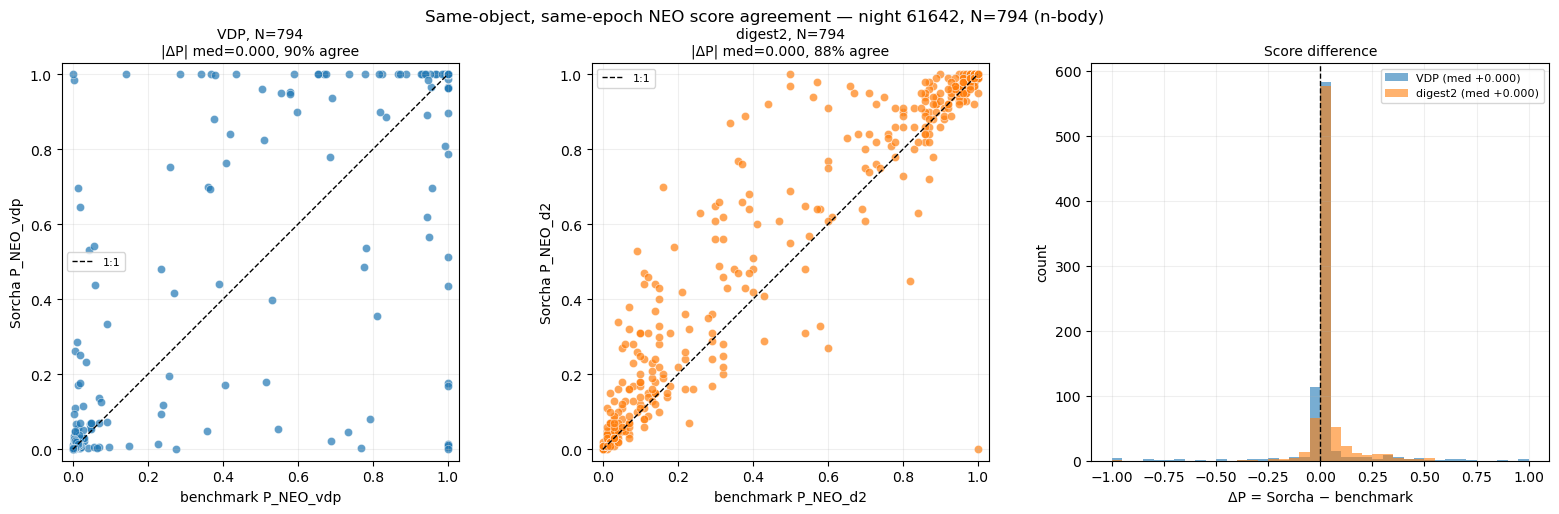

=== fraction each pipeline scores these NEOs as NEO (P>0.9) ===
  VDP:     benchmark 55.2%   sorcha 56.5%
  digest2: benchmark 60.7%   sorcha 64.2%


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5.2))

# panel 1: VDP scatter, same object same epoch
ax = axes[0]
ax.scatter(same.P_vdp_bench, same.P_vdp_sorcha, s=35, alpha=0.7, color='tab:blue', edgecolors='white', linewidths=0.4)
ax.plot([0,1],[0,1],'k--',lw=1, label='1:1')
ax.set_xlabel('benchmark P_NEO_vdp'); ax.set_ylabel('Sorcha P_NEO_vdp')
ax.set_title(f'VDP, N={len(same)}\n|ΔP| med={same.dP_vdp.abs().median():.3f}, '
             f'{100*(same.dP_vdp.abs()<0.1).mean():.0f}% agree', fontsize=10)
ax.legend(fontsize=8); ax.grid(alpha=0.2); ax.set_aspect('equal'); ax.set_xlim(-0.03,1.03); ax.set_ylim(-0.03,1.03)

# panel 2: digest2 scatter, same object same epoch
ax = axes[1]
ax.scatter(same.P_d2_bench, same.P_d2_sorcha, s=35, alpha=0.7, color='tab:orange', edgecolors='white', linewidths=0.4)
ax.plot([0,1],[0,1],'k--',lw=1, label='1:1')
ax.set_xlabel('benchmark P_NEO_d2'); ax.set_ylabel('Sorcha P_NEO_d2')
ax.set_title(f'digest2, N={len(same)}\n|ΔP| med={same.dP_d2.abs().median():.3f}, '
             f'{100*(same.dP_d2.abs()<0.1).mean():.0f}% agree', fontsize=10)
ax.legend(fontsize=8); ax.grid(alpha=0.2); ax.set_aspect('equal'); ax.set_xlim(-0.03,1.03); ax.set_ylim(-0.03,1.03)

# panel 3: ΔP distributions, both classifiers
ax = axes[2]
bins = np.linspace(-1, 1, 41)
ax.hist(same.dP_vdp, bins=bins, alpha=0.6, color='tab:blue',   label=f'VDP (med {same.dP_vdp.median():+.3f})')
ax.hist(same.dP_d2,  bins=bins, alpha=0.6, color='tab:orange', label=f'digest2 (med {same.dP_d2.median():+.3f})')
ax.axvline(0, color='k', lw=1, ls='--')
ax.set_xlabel('ΔP = Sorcha − benchmark'); ax.set_ylabel('count')
ax.set_title('Score difference', fontsize=10)
ax.legend(fontsize=8); ax.grid(alpha=0.2)

fig.suptitle(f'Same-object, same-epoch NEO score agreement — night 61642, N={len(same)} (n-body)', fontsize=12)
plt.tight_layout()
plt.savefig('Figures/mag245_nbody_bvs_sameNEO_scores.png', dpi=150, bbox_inches='tight')
plt.show()

print('=== fraction each pipeline scores these NEOs as NEO (P>0.9) ===')
print(f'  VDP:     benchmark {100*(same.P_vdp_bench>0.9).mean():.1f}%   sorcha {100*(same.P_vdp_sorcha>0.9).mean():.1f}%')
print(f'  digest2: benchmark {100*(same.P_d2_bench>0.9).mean():.1f}%   sorcha {100*(same.P_d2_sorcha>0.9).mean():.1f}%')

## 5. Full object table — same-epoch NEOs

Every quantity for each identity-matched, same-night NEO: position (RA/Dec), ecliptic
rates (vlam/vbeta), magnitude, and both scores (VDP, digest2) on both sides, plus the raw same-night position
offset (benchmark snapshot vs Sorcha tracklet; not motion-corrected) and the score differences.

In [9]:
# ---- pull full per-object columns for the same-epoch NEOs ----
b_full = pd.read_parquet('outputs/phase2_benchmark_s3m_nbody_mag245/benchmark_comparison_s3m_nbody_mag245.parquet',
    columns=['s3m_objid','mean_ra','mean_dec','vlam','vbeta','mean_mag','H','e',
             'P_NEO_vdp','P_NEO_d2']).set_index('s3m_objid')
s_full = pd.read_parquet('sorcha_comparison_case1_nbody_Vband.parquet',
    columns=['ObjID','night','mean_ra','mean_dec','vlam','vbeta','mean_mag_V',
             'P_NEO_vdp_Vband','P_NEO_d2'])
s_full = s_full[s_full.night == 61642].set_index('ObjID')

ids = same.index  # common same-epoch NEOs
tbl = pd.DataFrame(index=ids)
tbl['ra_bench']   = b_full.loc[ids, 'mean_ra']
tbl['ra_sorcha']  = s_full.loc[ids, 'mean_ra']
tbl['dec_bench']  = b_full.loc[ids, 'mean_dec']
tbl['dec_sorcha'] = s_full.loc[ids, 'mean_dec']
tbl['vlam_bench']   = b_full.loc[ids, 'vlam']
tbl['vlam_sorcha']  = s_full.loc[ids, 'vlam']
tbl['vbeta_bench']  = b_full.loc[ids, 'vbeta']
tbl['vbeta_sorcha'] = s_full.loc[ids, 'vbeta']
tbl['mag_bench']  = b_full.loc[ids, 'mean_mag']
tbl['mag_sorcha'] = s_full.loc[ids, 'mean_mag_V']
tbl['H']  = b_full.loc[ids, 'H']
tbl['e']  = b_full.loc[ids, 'e']
tbl['P_vdp_bench']   = same.P_vdp_bench
tbl['P_vdp_sorcha']  = same.P_vdp_sorcha
tbl['P_d2_bench']    = same.P_d2_bench
tbl['P_d2_sorcha']   = same.P_d2_sorcha

# derived: sky separation (deg, small-angle), velocity offset, score diffs
import numpy as np
dra  = (tbl.ra_sorcha - tbl.ra_bench) * np.cos(np.radians(tbl.dec_bench))
ddec = tbl.dec_sorcha - tbl.dec_bench
tbl['sky_sep_deg'] = np.hypot(dra, ddec)
tbl['dv_deg_day']  = np.hypot(tbl.vlam_sorcha - tbl.vlam_bench, tbl.vbeta_sorcha - tbl.vbeta_bench)
tbl['dmag']    = tbl.mag_sorcha - tbl.mag_bench
tbl['dP_vdp']  = tbl.P_vdp_sorcha - tbl.P_vdp_bench
tbl['dP_d2']   = tbl.P_d2_sorcha  - tbl.P_d2_bench

tbl = tbl.round(4).sort_values('dP_vdp', key=lambda s: s.abs(), ascending=False)
print(f'{len(tbl)} identity-matched, same-night (night 61642) NEOs')
print(f"median raw sky-sep={tbl.sky_sep_deg.median():.4f} deg   median |dv|={tbl.dv_deg_day.median():.4f} deg/day   "
      f"median |dmag|={tbl.dmag.abs().median():.4f}")
display(tbl)

794 identity-matched, same-night (night 61642) NEOs
median raw sky-sep=0.0776 deg   median |dv|=0.0192 deg/day   median |dmag|=0.0895


,ra_bench,ra_sorcha,dec_bench,dec_sorcha,vlam_bench,vlam_sorcha,vbeta_bench,vbeta_sorcha,mag_bench,mag_sorcha,...,e,P_vdp_bench,P_vdp_sorcha,P_d2_bench,P_d2_sorcha,sky_sep_deg,dv_deg_day,dmag,dP_vdp,dP_d2
S0000e92a,48.2278,48.8249,-0.0958,0.2975,2.0022,1.9878,0.5900,0.6177,23.0359,23.8127,...,0.6380,0.0,1.0000,1.00,1.00,0.7150,0.0313,0.7767,1.0000,0.00
S0000NWGa,2.1500,1.4901,-30.2748,-29.6969,-0.6741,-0.7034,1.9855,2.0074,22.2620,22.7822,...,0.4761,1.0,0.0000,1.00,1.00,0.8116,0.0366,0.5202,-1.0000,0.00
S0000kyza,298.0045,298.0622,-19.6609,-19.6714,0.2831,0.2619,-0.1076,-0.0970,23.6422,23.8270,...,0.3838,1.0,0.0071,0.99,0.99,0.0554,0.0237,0.1848,-0.9929,0.00
S0000BUga,336.8534,336.8407,-9.8284,-9.8257,-0.0413,-0.0748,0.0389,0.0501,23.0123,23.0473,...,0.4310,1.0,0.0127,0.82,0.45,0.0128,0.0353,0.0349,-0.9873,-0.37
S0000t4oa,297.9427,298.0037,-18.9414,-18.9343,0.3159,0.2943,-0.0241,-0.0145,24.1181,23.8187,...,0.4922,1.0,0.0154,0.99,1.00,0.0582,0.0236,-0.2993,-0.9846,0.01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
S00004lxa,316.9685,316.8641,-8.9053,-8.9084,-0.6130,-0.6242,0.1667,0.1700,23.8344,23.9985,...,0.7308,1.0,1.0000,1.00,1.00,0.1032,0.0117,0.1641,0.0000,0.00
S00003hka,305.6032,305.5124,-34.3079,-34.2962,-0.3286,-0.3372,0.1350,0.1425,23.4425,23.4783,...,0.4513,1.0,1.0000,1.00,1.00,0.0760,0.0114,0.0358,0.0000,0.00
S000035Ia,352.4490,352.3704,-0.9736,-1.0091,-0.3309,-0.3436,-0.0093,-0.0044,23.3730,23.4096,...,0.5115,1.0,1.0000,1.00,1.00,0.0863,0.0136,0.0366,0.0000,0.00
S00001Vga,359.3575,359.2160,0.4991,0.4673,-0.4410,-0.4648,0.0807,0.0897,21.0561,21.1549,...,0.4125,1.0,1.0000,1.00,1.00,0.1450,0.0254,0.0988,0.0000,0.00


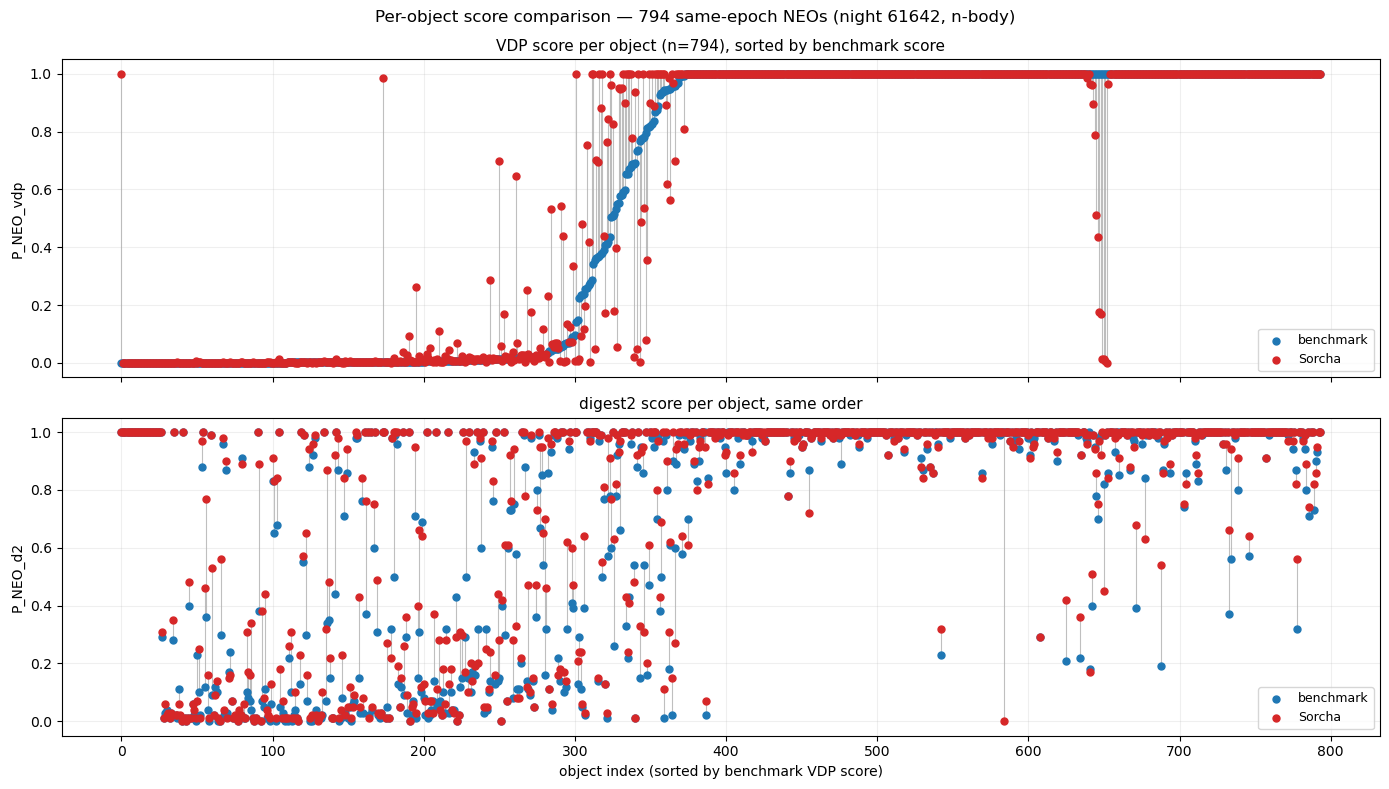

saved outputs/mag245_nbody_same_epoch_neo_table.csv


In [10]:
# ---- per-object comparison plot: both classifiers, benchmark vs sorcha, connected by object ----
plot_tbl = tbl.sort_values('P_vdp_bench')
x = np.arange(len(plot_tbl))

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

ax = axes[0]
for xi, (oid, row) in zip(x, plot_tbl.iterrows()):
    ax.plot([xi, xi], [row.P_vdp_bench, row.P_vdp_sorcha], color='grey', lw=0.8, alpha=0.5, zorder=1)
ax.scatter(x, plot_tbl.P_vdp_bench,  s=25, color='tab:blue',  label='benchmark', zorder=3)
ax.scatter(x, plot_tbl.P_vdp_sorcha, s=25, color='tab:red',   label='Sorcha',    zorder=3)
ax.set_ylabel('P_NEO_vdp'); ax.set_ylim(-0.05, 1.05)
ax.legend(fontsize=9); ax.grid(alpha=0.2)
ax.set_title(f'VDP score per object (n={len(plot_tbl)}), sorted by benchmark score', fontsize=11)

ax = axes[1]
for xi, (oid, row) in zip(x, plot_tbl.iterrows()):
    ax.plot([xi, xi], [row.P_d2_bench, row.P_d2_sorcha], color='grey', lw=0.8, alpha=0.5, zorder=1)
ax.scatter(x, plot_tbl.P_d2_bench,  s=25, color='tab:blue',  label='benchmark', zorder=3)
ax.scatter(x, plot_tbl.P_d2_sorcha, s=25, color='tab:red',   label='Sorcha',    zorder=3)
ax.set_ylabel('P_NEO_d2'); ax.set_ylim(-0.05, 1.05)
ax.set_xlabel('object index (sorted by benchmark VDP score)')
ax.legend(fontsize=9); ax.grid(alpha=0.2)
ax.set_title('digest2 score per object, same order', fontsize=11)

fig.suptitle(f'Per-object score comparison — {len(plot_tbl)} same-epoch NEOs (night 61642, n-body)', fontsize=12)
plt.tight_layout()
plt.savefig('Figures/mag245_nbody_bvs_sameNEO_perobject.png', dpi=150, bbox_inches='tight')
plt.show()

tbl.to_csv('outputs/mag245_nbody_same_epoch_neo_table.csv')
print('saved outputs/mag245_nbody_same_epoch_neo_table.csv')

## 6. Investigation roadmap: VDP zeros and per-object disagreements

This figure exposes structure that the aggregate curves cannot. Most strikingly, many true NEOs receive a VDP score at or near zero while digest2 assigns substantial probability. If those VDP values are exact zeros, lowering the classification threshold cannot recover them: this would be a structural recall limit rather than ordinary threshold tuning. The narrow group near the high-score plateau where benchmark VDP is approximately 1 but Sorcha spans almost the entire score range is a second, distinct failure mode worth isolating.

### First: establish what the apparent structures really are

1. Count **exact zeros** separately from merely very small values for both benchmark and Sorcha VDP scores. Examine the same objects' digest2 score distributions. Exact zero may indicate zero NEO density, an out-of-support feature vector, map/bin assignment, or explicit clipping; a small nonzero value is instead a calibration/ranking question.
2. Define named object cohorts and retain their `ObjID`/`s3m_objid`: **VDP-zero / digest2-high**, **benchmark-high / Sorcha-low VDP** (the apparent spike), the reverse disagreement, and strong agreement at zero or one. Report counts and fractions before inspecting examples.
3. Check whether the apparent spike is a real shared population or a sorting artifact. The x-axis is sorted by benchmark VDP and has large tied plateaus at exactly 0 and 1, so adjacent indices are not automatically physically related. Tabulate the actual object identities and score differences.

### Trace the VDP zero back through the model

For every zero/high-disagreement cohort, attach the probability-map file and cell, magnitude bin, elongation bin, sky position, `vlam`, `vbeta`, and distance to each bin or cell boundary. Then inspect the underlying NEO and non-NEO density contributions before the probability ratio is formed. This separates several possible explanations: genuinely empty NEO support, sparse training statistics, hard map boundaries, an uncovered feature-space region, numerical clipping, or an implementation issue.

### Separate model behavior from benchmark-Sorcha input differences

The identity match fixes the object and night, but the benchmark snapshot and Sorcha tracklet do not necessarily supply identical epochs or feature vectors. Compare their magnitude, velocity, position, map selection, and bin assignment object by object. A decisive diagnostic would score an identical frozen feature vector through both paths, then perturb one input at a time. That tells us whether a large score jump comes from the VDP implementation, a discrete map/bin transition, or realistic observational/tracklet differences.

### Scientific questions this can support

- Where in orbit/geometry/velocity/magnitude space does VDP have a hard recall blind spot?
- Does digest2 rescue a coherent physical population, or is its advantage distributed broadly?
- Are the zero scores concentrated in a small number of probability maps or cells that can be improved directly?
- How much performance could a hybrid rule recover, and what contamination would that rescue cost?
- Are the benchmark-Sorcha disagreements calibration noise, boundary sensitivity, or evidence that the two pipelines construct meaningfully different inputs for the same object?

A useful end product would be a small failure-mode taxonomy with representative objects, cohort-level completeness/contamination, and a causal explanation for each score pattern.